# Final Project: Student Habits vs Academic Performance


```
Student: Charlie (Yang) Vang
Professor: Dr. Siva Jasthi
Class: Data Science II – DSCI 2002
Year: Spring 2025
```

Dataset being used: https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance/data

## 1. Data Perperation

### Import Data

In [ ]:
import pandas as pd
import numpy as np
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-habits-vs-academic-performance


### Loading the Data

In [ ]:
df = pd.read_csv('/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv')
df = pd.DataFrame(df)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

### Missing Values

In [ ]:
df['parental_education_level'].describe()

,parental_education_level
count,909
unique,3
top,High School
freq,392


In [ ]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [ ]:
df = df.drop('student_id', axis=1) # Drop student ID

In [ ]:
df.isna().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


### Label Encoding


Label Encoding

In [ ]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
df['parental_education_level'] = le.fit_transform(df['parental_education_level'])
df['diet_quality'] = le.fit_transform(df['diet_quality'])
df['internet_quality'] = le.fit_transform(df['internet_quality'])
df['gender'] = le.fit_transform(df['gender'])
df['exercise_frequency'] = le.fit_transform(df['exercise_frequency'])
df['extracurricular_participation'] = le.fit_transform(df['extracurricular_participation'])
df['part_time_job'] = le.fit_transform(df['part_time_job'])

df['gender'].unique()

array([0, 1, 2])

In [ ]:
df.info() # No more obejcts yes!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   int64  
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   int64  
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   int64  
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   int64  
 11  internet_quality               1000 non-null   int64  
 12  mental_health_rating           1000 non-null   in

## 2. Exploratory Analysis

### Visualizations of Features

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Distribution

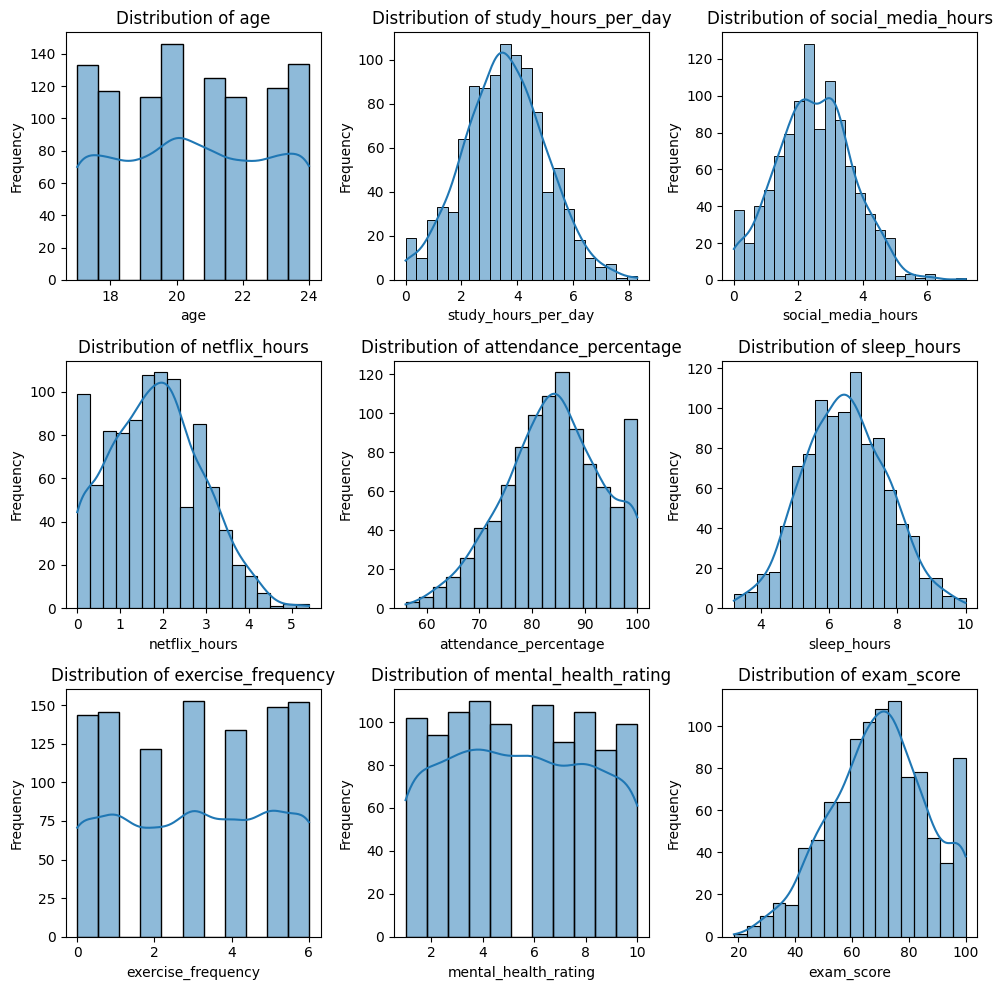

In [ ]:
columns = ['age',
           'study_hours_per_day',
           'social_media_hours',
           'netflix_hours',
           'attendance_percentage',
           'sleep_hours',
           'exercise_frequency',
           'mental_health_rating',
           'exam_score']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

axes = axes.flatten()

# Iterate through the columns and create distribution plots
for i, col in enumerate(columns):
    if i < len(axes):  # Check if the current index is within the axes
      sns.histplot(df[col], ax=axes[i], kde=True)
      axes[i].set_title(f'Distribution of {col}')
      axes[i].set_xlabel(col)
      axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Correaltion Heat Map

<Axes: >

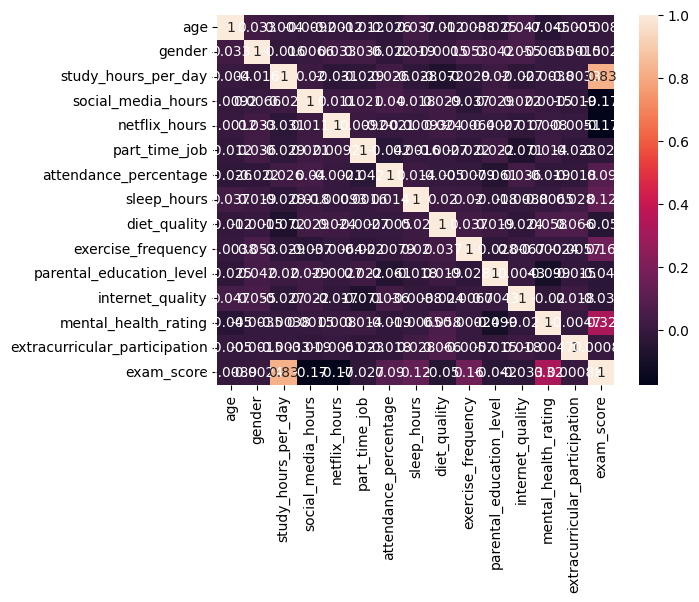

In [ ]:
corr = df.corr()
sns.heatmap(corr, annot=True)

## 3. Modeling

### Feature Selection

In [ ]:
X = df.drop('exam_score', axis=1) # Everything but exam score
y = df['exam_score'] # Target Variable

### Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=23)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 31.84
R-squared: 0.90


### K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

print(f"KNN MSE: {mse:.2f}")
print(f"KNN R-squared: {r2:.2f}")

KNN MSE: 125.38
KNN R-squared: 0.59


### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score

clf = DecisionTreeRegressor(random_state=23)
clf.fit(X_train, y_train)

y_pred_clf = clf.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_clf)
r2 = r2_score(y_test, y_pred_clf)

print(f"Decision Tree MSE: {mse:.2f}")
print(f"Decision Tree R-squared: {r2:.2f}")

Decision Tree MSE: 94.34
Decision Tree R-squared: 0.69


### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=23, n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse:.2f}")
print(f"Random Forest R-squared: {r2:.2f}")

Random Forest MSE: 38.41
Random Forest R-squared: 0.87


## 4. Ensemble Model

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import cross_val_score

models = [knn, clf, rf]
labels = ['KNN', 'Decision Tree', 'Random Forest']

voting_reg = VotingRegressor(
    estimators=[
        (labels[0], knn),
        (labels[1], clf),
        (labels[2], rf)
    ]
)

In [ ]:
labels2 = ['KNN', 'Decision Tree', 'Random Forest', 'Voting Regressor']

for model, label in zip([knn, clf, rf, voting_reg], labels2):
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{label} R-squared: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

KNN R-squared: 0.56 (+/- 0.07)
Decision Tree R-squared: 0.69 (+/- 0.06)
Random Forest R-squared: 0.85 (+/- 0.04)
Voting Regressor R-squared: 0.81 (+/- 0.04)


## 5. K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

def cross_validation(reg_model, X_scaler, y, cv):
    scores = cross_val_score(
      reg_model, X_scaler, y,
      scoring="neg_mean_squared_error", cv=cv)
    rmse_scores = np.sqrt(-scores)
    print("Scores:", rmse_scores)
    print("Mean:", rmse_scores.mean())
    print("Standard Deviation:", rmse_scores.std())

print("----- KNN Model Cross Validation ------")
knn = KNeighborsRegressor()
cross_validation(knn, X, y, kf)
print("")

print("----- Decision Tree Regression Model Cross Validation ------")
clf = DecisionTreeRegressor()
cross_validation(clf, X, y, kf)
print("")

print("----- Random Forest Regression Model Cross Validation ------")
rf = RandomForestRegressor()
cross_validation(rf, X, y, kf)
print("")

----- KNN Model Cross Validation ------
Scores: [10.90474062 11.58930938 11.57301931 10.52647633 10.63321776 11.594626
 10.91997601 10.02520105 11.30323688 11.15601452]
Mean: 11.022581786554762
Standard Deviation: 0.49647513403115784

----- Decision Tree Regression Model Cross Validation ------
Scores: [10.03058822  9.69097002 10.18930321  8.8468695   9.15106551  9.07685518
  9.23783524  9.19274714 11.04229596 10.88557761]
Mean: 9.734410760990459
Standard Deviation: 0.7370665752244944

----- Random Forest Regression Model Cross Validation ------
Scores: [6.39476702 5.82636995 6.275583   5.481552   6.403863   5.63246442
 6.51102623 5.77093187 7.11967274 7.34925642]
Mean: 6.276548664688782
Standard Deviation: 0.5875286161485944



Summary:


*   Even though simple, Lineear Regression performed the best out of all models.
*   Simpler models sometimes win especially when relationships in the data are clear and linear.

